# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.
Removendo duplicatas, restam **1'812** entradas.


In [20]:
%%html
<link rel="stylesheet" href="./style.css">

In [ ]:
import import_ipynb  # noqa: F401
from treatment import (  # type: ignore
    f3_categorical_columns,
    f3_df,
    f3_numerical_columns,
)


In [22]:
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA

In [23]:
# Identify indexes of categorical indexes
indexes_of2_categorical_columns = [
    f3_df.columns.get_loc(col) for col in f3_categorical_columns
]

In [24]:
clustered_df_through_kp = f3_df.copy()

k_prototypes_protocol = KPrototypes(n_clusters=6, random_state=42)

clusters = k_prototypes_protocol.fit_predict(
    clustered_df_through_kp, categorical=indexes_of2_categorical_columns
)

# Add column describing the cluster to the database
clustered_df_through_kp["Cluster"] = clusters


Número de clusters: 6
Número de variáveis: 16

Centroides:
[['-0.0095096113557427' '-0.33835572915943074' '0.7748711486542543'
  '1.4266044257169732' '-1.26281413725845' '1.07949973844177'
  '-0.026410838538037277' '-0.008723173833178863' '-1.0517949501124215'
  '1.2105037758967665' '0.1527911373693582' '0.007756686778928361'
  '-0.2190084505647215' 'delux ponni' 'clay' 'dry']
 ['0.7276004927640657' '1.3763929089299864' '-0.3513088344488499'
  '0.6705332881331292' '-0.046870308887780654' '-1.023166436132796'
  '0.7146579056052184' '0.7322027172637057' '1.34710264888929'
  '-0.13465228341103286' '-0.33102115816046146' '-0.21812645874522305'
  '0.004413079749533396' 'ponmani' 'clay' 'dry']
 ['-1.0804539451347874' '-0.640761653629355' '-0.9264823022139553'
  '-0.8188944035019958' '-0.07518096948325043' '0.9168852639529071'
  '-1.033811211363086' '-1.0924740372701192' '-0.7093060350858362'
  '-0.8921880953955181' '-0.07107205734813311' '-0.4845935940864239'
  '0.3321055551958436' 'ponmani'

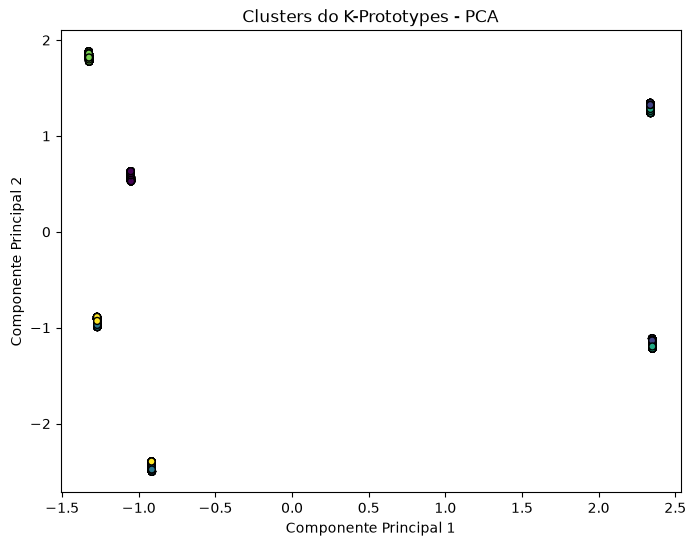

In [25]:
centroides = k_prototypes_protocol.cluster_centroids_

print("Número de clusters:", k_prototypes_protocol.n_clusters)
print("Número de variáveis:", len(clustered_df_through_kp.columns) - 1)

print("\nCentroides:")
print(centroides)


pca = PCA(n_components=2)

xn = pca.fit_transform(clustered_df_through_kp[f3_numerical_columns])
plt.figure(figsize=(8, 6))

plt.scatter(xn[:, 0], xn[:, 1], marker="o", c=clusters, s=25, edgecolor="k")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters do K-Prototypes - PCA")

plt.show()